In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score   

In [3]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 1.3 MB/s eta 0:00:02
   -------- ------------------------------- 0.5/2.3 MB 1.3 MB/s eta 0:00:02
   -------- ------------------------------- 0.5/2.3 MB 1.3 MB/s eta 0:00:02
   -------- ------------------------------- 0.5/2.3 MB 1.3 MB/s eta 0:00:02
   ------------- -------------------------- 0.8/2.3 MB 524.3 kB/s eta 0:00:03
   ------------- -------------------------- 0.8/2.3 MB 524.3 kB/s eta 0:00:03
   ------------- -------------------------- 0.8/2.3 MB 524.3 kB/s eta 0:00:03

In [9]:
df =pd.read_csv("Mall_Customers.csv",encoding = "Latin1")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [32]:
from sklearn.preprocessing import LabelEncoder   
le = LabelEncoder()
genderLE=le.fit_transform(df["Gender"])

df["Gender_Encoded"] = genderLE
df=df.drop("Gender",axis =1)

df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


C:\Users\Sandeep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sandeep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sandeep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sandeep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak o

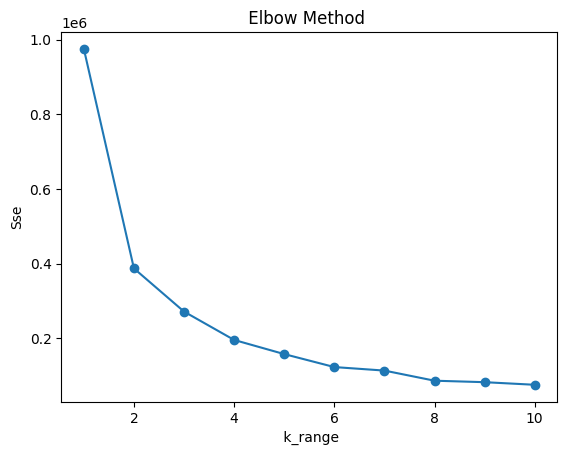

In [36]:
x = df[["CustomerID","Gender_Encoded","Age","Annual Income (k$)","Spending Score (1-100)"]]
Sse = []

k_range = range(1,11)

for k in k_range :
    kmeans = KMeans(n_clusters = k, random_state =42)
    kmeans.fit(x)
    Sse.append(kmeans.inertia_)

plt.plot(k_range,Sse, marker="o")
plt.xlabel(" k_range")
plt.ylabel("Sse")
plt.title(" Elbow Method  ")
plt.show()

In [41]:
features =df[["CustomerID","Gender_Encoded","Age","Annual Income (k$)","Spending Score (1-100)"]]

kmeans = KMeans(n_clusters =3, random_state =42)
df["Cluster"] = kmeans.fit_predict(features)
df.head()

cluster_name = {0: "Daily" ,1: " Promotion ", 2: "Weekend"}
df["Cluster_Name"] = df["Cluster"].map(cluster_name)
df.head()

C:\Users\Sandeep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,Cluster,Cluster_Name
0,1,19,15,39,1,2,Weekend
1,2,21,15,81,1,2,Weekend
2,3,20,16,6,0,2,Weekend
3,4,23,16,77,0,2,Weekend
4,5,31,17,40,0,2,Weekend


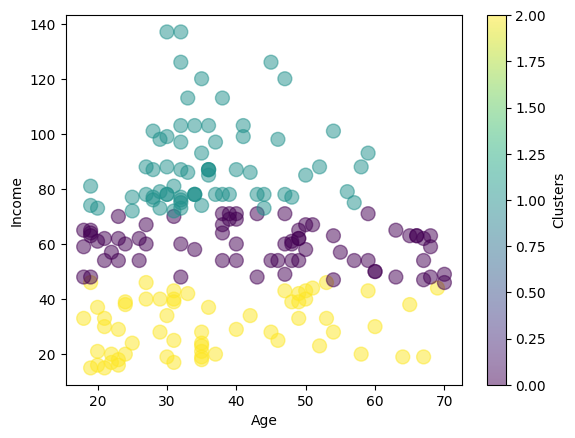

In [45]:
plt.scatter(df["Age"],df["Annual Income (k$)"], c =df["Cluster"], cmap="viridis", marker="o",s=100,alpha =0.5)
plt.xlabel("Age")
plt.ylabel("Income")
plt.colorbar(label="Clusters")
plt.show()


In [47]:
print(silhouette_score(features,df["Cluster"]))

0.3766801400675223


In [49]:
import pickle 
pickle.dump(KMeans,open("Kmeans.pkl",'wb'))

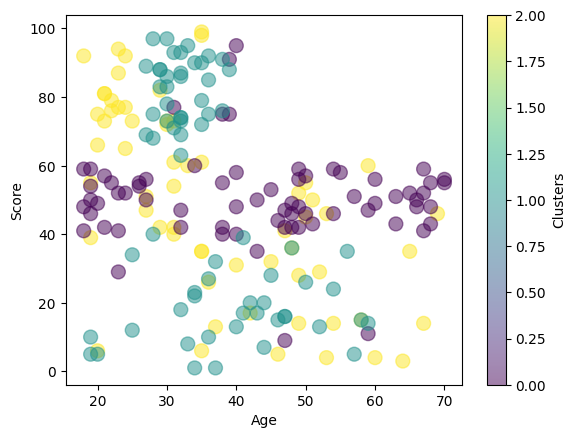

In [51]:
plt.scatter(df["Age"],df["Spending Score (1-100)"], c =df["Cluster"], cmap="viridis", marker="o",s=100,alpha =0.5)
plt.xlabel("Age")
plt.ylabel("Score")
plt.colorbar(label="Clusters")
plt.show()


In [78]:
KMeans=pickle.load(open("Kmeans.pkl","rb"))
def clustering(CustomerID,Age,Annual_Income,Spending_Score,Gender_Encoded):
  new_customer=np.array([[CustomerID,Age, Annual_Income,Spending_Score,Gender_Encoded]])
  predicted_cluster = KMeans.predict(new_customer)

  if predicted_cluster == 0:
      return "Daily"
  if predicted_cluster == 1:
       return "Promo"
  if predicted_cluster == 2:
       return "weekend"

    

In [79]:
CustomerID =1
Age =20
Annual_Income =15
Spending_Score =39
Gender_Encoded = 1
predicted_cluster = clustering(CustomerID,Age,Annual_Income,Spending_Score,Gender_Encoded)

print(" the new customer assigned ",predicted_cluster)





TypeError: _BaseKMeans.predict() missing 1 required positional argument: 'X'